<a href="https://colab.research.google.com/github/diomani-ouattara/Portfolio-Data-scientist/blob/main/term_deposit_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Term Deposit Subscription Prediction
**European Banking ML System — Customer Intention Classification**

Goals:
- Predict if a customer will subscribe to a term deposit (≥81% accuracy, 5-fold CV)
- Identify high-value customer segments
- Determine most influential features

In [3]:
#  imports Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42


## 1. Load Data

In [4]:
print("Please upload your Term deposit file:")
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Please upload your Term deposit file:


Saving term-deposit-marketing-2020.csv to term-deposit-marketing-2020.csv


In [5]:

print(f'Shape: {df.shape}')
df.head()

Shape: (40000, 14)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [6]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['y'].value_counts())
print(f"Subscription rate: {df['y'].eq('yes').mean():.1%}")

=== Data Types ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
y            object
dtype: object

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

=== Target Distribution ===
y
no     37104
yes     2896
Name: count, dtype: int64
Subscription rate: 7.2%


Data are numerical and categoricals, no missing value and only  7.2% subcribed.

## 2. Exploratory Data Analysis

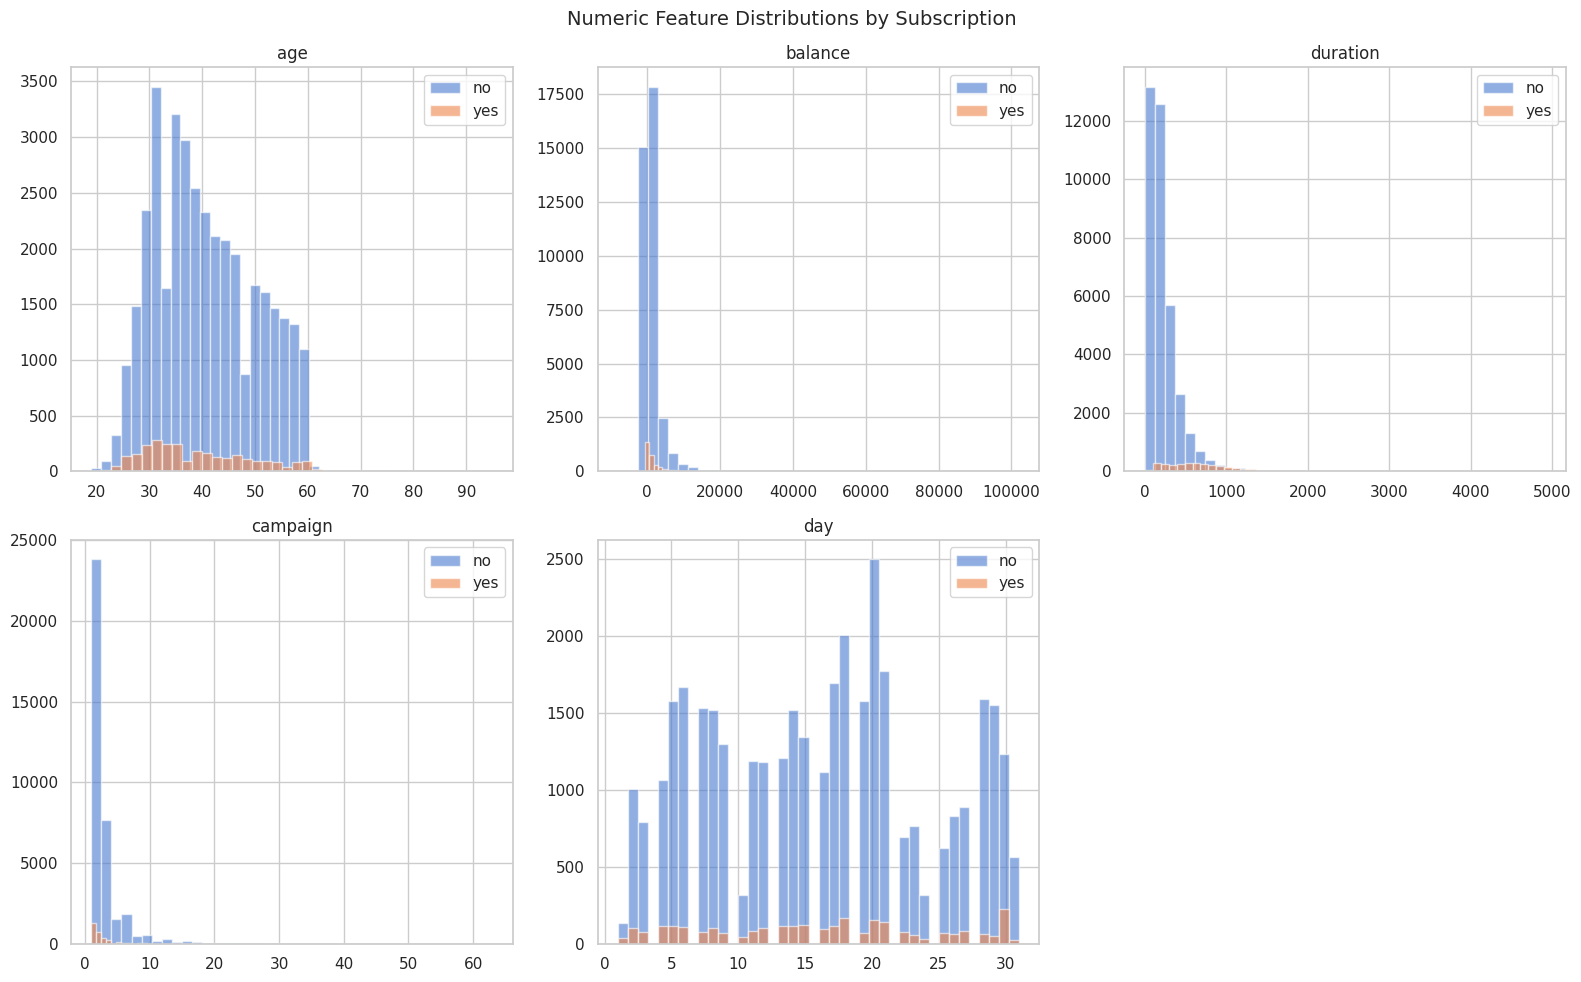

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Numeric Feature Distributions by Subscription', fontsize=14)

numeric_cols = ['age', 'balance', 'duration', 'campaign', 'day']
for ax, col in zip(axes.flat, numeric_cols):
    for label, grp in df.groupby('y'):
        ax.hist(grp[col], bins=40, alpha=0.6, label=label)
    ax.set_title(col)
    ax.legend()
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

the age-sucrition is left skewed, you can observe that before 30, the number was growing and after that it decreased and start growing again close to 60.

Less you have campaign more you have a  yes

the duration and the days are  affect the subcription rate  as well

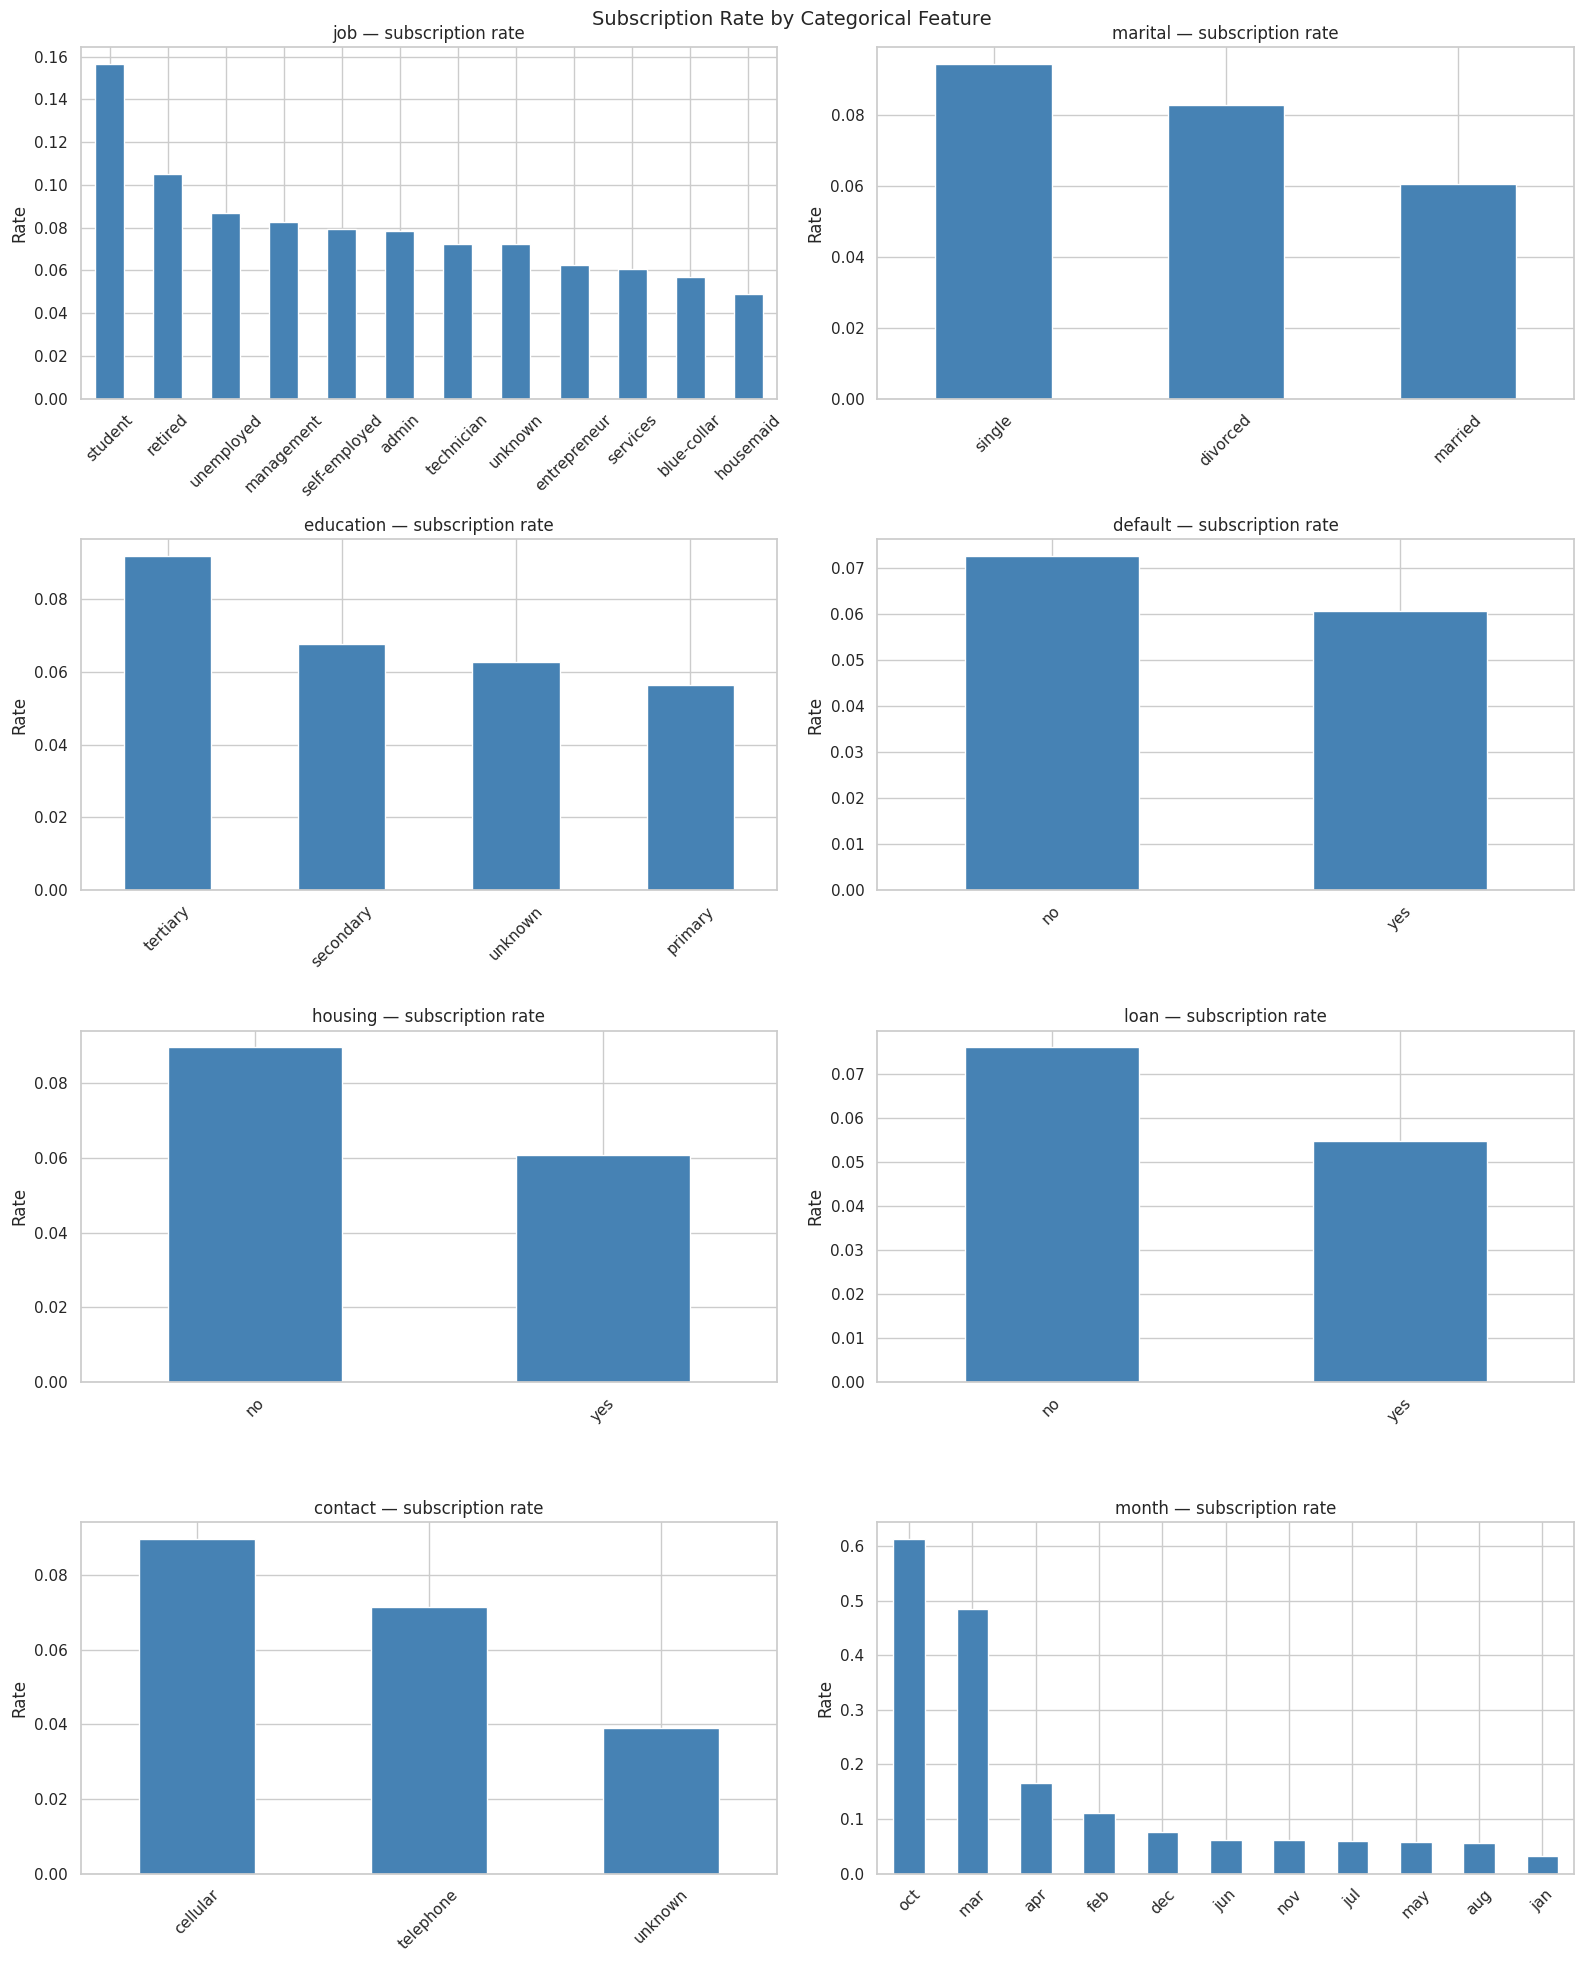

In [8]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Subscription Rate by Categorical Feature', fontsize=14)

for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} — subscription rate')
    ax.set_xlabel('')
    ax.set_ylabel('Rate')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

(Students,retired)  and (singles and divorced) are more likely open to a subcription than the others.

Tertiary and secondary educated people showed more interest for the offer.  

People with a loan or a house have less subcription rate

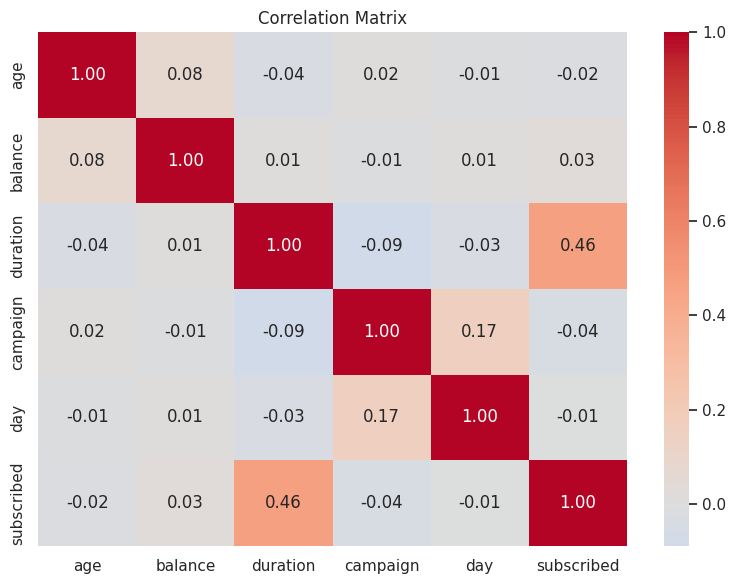

In [9]:
# Correlation heat-map (numeric only)
num_df = df[['age', 'balance', 'duration', 'campaign', 'day']].copy()
num_df['subscribed'] = (df['y'] == 'yes').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Duration, age and balance are positively correlated

Campaign, day and durtation can affect negatively also.

## 3. Preprocessing

In [10]:
data = df.copy()

# Encode target
data['y'] = (data['y'] == 'yes').astype(int)

# Label-encode all categoricals
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

# Month → ordinal (keeps seasonality signal)
month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
data['month'] = df['month'].str.lower().map(month_order)

# Feature engineering
data['duration_min']      = data['duration'] / 60          # seconds → minutes
data['high_balance']      = (data['balance'] > data['balance'].median()).astype(int)
data['many_contacts']     = (data['campaign'] > 3).astype(int)
data['log_balance']       = np.log1p(data['balance'].clip(lower=0))
data['age_group']         = pd.cut(data['age'], bins=[0,30,40,50,60,100],
                                   labels=[0,1,2,3,4]).astype(int)

X = data.drop('y', axis=1)
y = data['y']
print('Features:', X.shape[1])
print('Class balance:', y.value_counts().to_dict())

Features: 18
Class balance: {0: 37104, 1: 2896}


We have 18 features and we can see that the class are not properly balanced

## 4. Model Comparison — 5-Fold Stratified CV

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=6, use_label_encoder=False,
        eval_metric='logloss', random_state=SEED,
        scale_pos_weight=(y==0).sum()/(y==1).sum()
    ),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression       0.9331 ± 0.0014
Decision Tree             0.9333 ± 0.0017
Random Forest             0.9086 ± 0.0012
Gradient Boosting         0.9380 ± 0.0016
XGBoost                   0.8911 ± 0.0022


Models accuracy and standard deviation

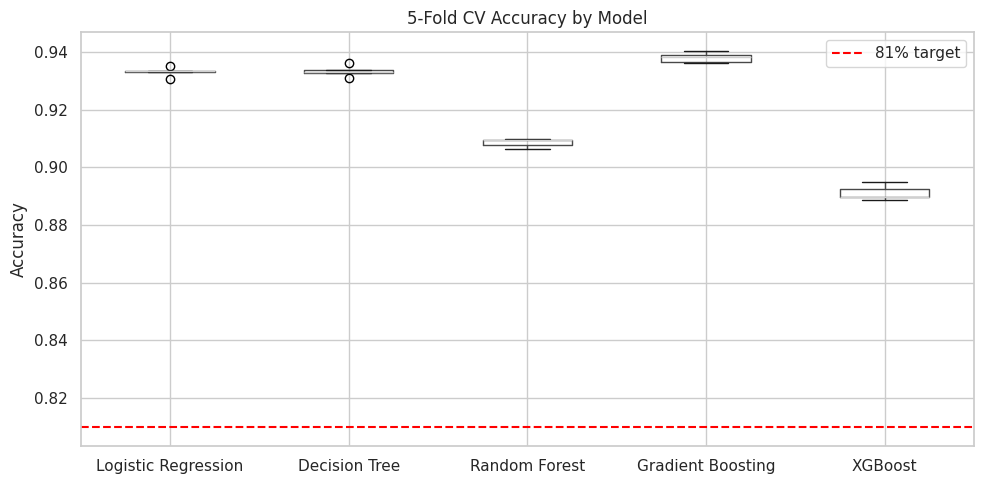


Best model: Gradient Boosting — 0.9380


In [12]:
# Visualise CV results
res_df = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
res_df.boxplot()
plt.axhline(0.81, color='red', linestyle='--', label='81% target')
plt.title('5-Fold CV Accuracy by Model')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

best_name = max(results, key=lambda k: results[k].mean())
print(f'\nBest model: {best_name} — {results[best_name].mean():.4f}')

Gradiant Boosting is the best model

## 5. Best Model — Detailed Evaluation

              precision    recall  f1-score   support

          No       0.96      0.98      0.97      7421
         Yes       0.64      0.41      0.50       579

    accuracy                           0.94      8000
   macro avg       0.80      0.70      0.74      8000
weighted avg       0.93      0.94      0.93      8000

ROC-AUC: 0.9487


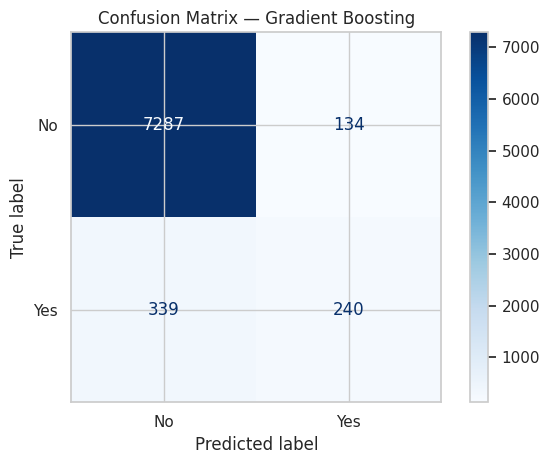

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['No', 'Yes']
).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

## 6. Feature Importance

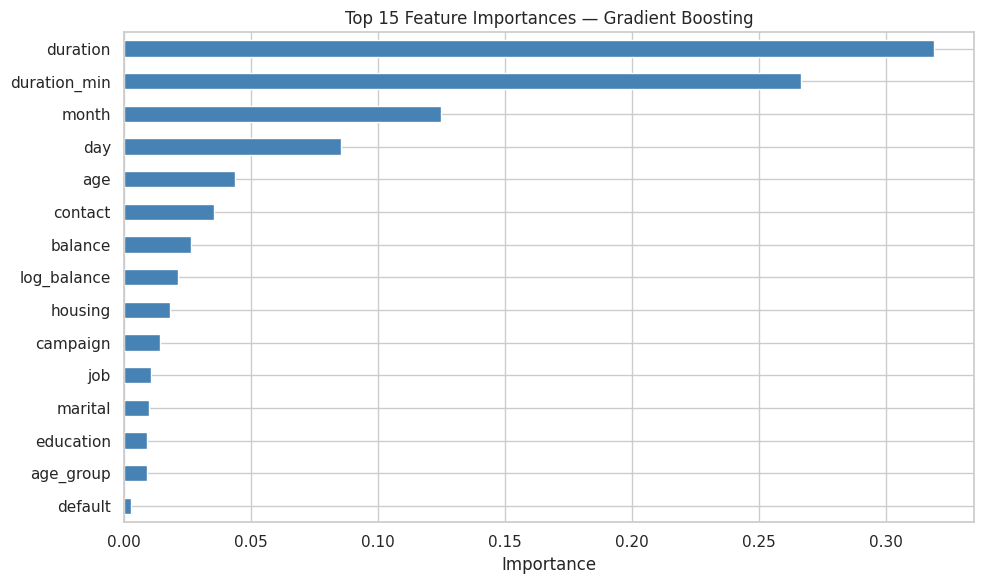


Top 10 features:
duration        0.318895
duration_min    0.266581
month           0.124711
day             0.085648
age             0.043760
contact         0.035585
balance         0.026240
log_balance     0.021209
housing         0.018299
campaign        0.014036


In [14]:
# Extract feature importance from the best tree-based model
clf = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model

if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    importances.head(15).plot(kind='barh', color='steelblue', edgecolor='white')
    plt.gca().invert_yaxis()
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('\nTop 10 features:')
    print(importances.head(10).to_string())
else:
    # Logistic Regression coefficients
    coef = pd.Series(np.abs(clf.coef_[0]), index=X.columns).sort_values(ascending=False)
    coef.head(15).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title('Feature Coefficients (absolute)')
    plt.show()

The 10 most important features that affect the subcription rate.

## 7. Customer Segmentation Analysis

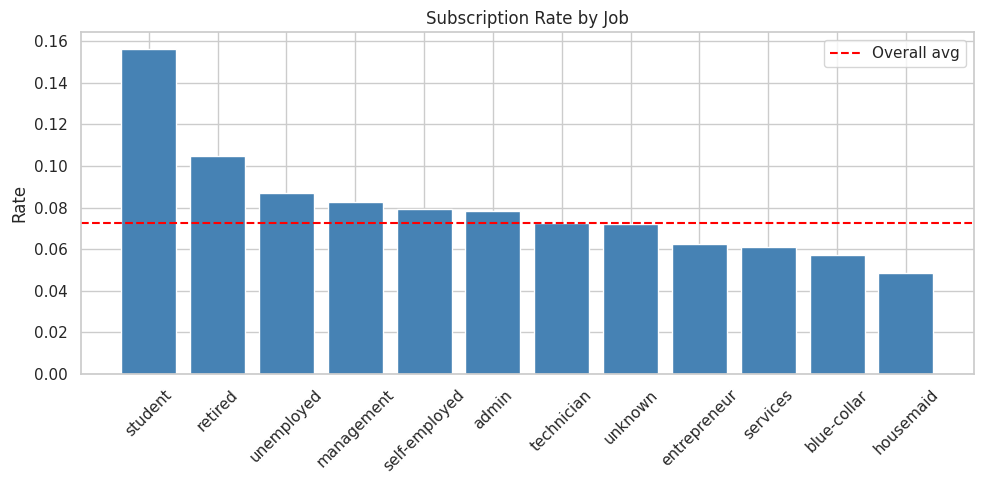

                   rate     n
job                          
student        0.156489   524
retired        0.105080  1437
unemployed     0.086957  1104
management     0.082782  8166
self-employed  0.079208  1414
admin          0.078296  4483
technician     0.072534  6852
unknown        0.072340   235
entrepreneur   0.062633  1405
services       0.060870  3910
blue-collar    0.057018  9383
housemaid      0.048758  1087


In [15]:
seg = df.copy()
seg['subscribed'] = (seg['y'] == 'yes').astype(int)

# ── Segment 1: Job × Subscription rate ───────────────────────────────────────
job_rates = (
    seg.groupby('job')['subscribed']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
    .sort_values('rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(job_rates.index, job_rates['rate'], color='steelblue', edgecolor='white')
ax.axhline(seg['subscribed'].mean(), color='red', linestyle='--', label='Overall avg')
ax.set_title('Subscription Rate by Job')
ax.set_ylabel('Rate')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
print(job_rates)

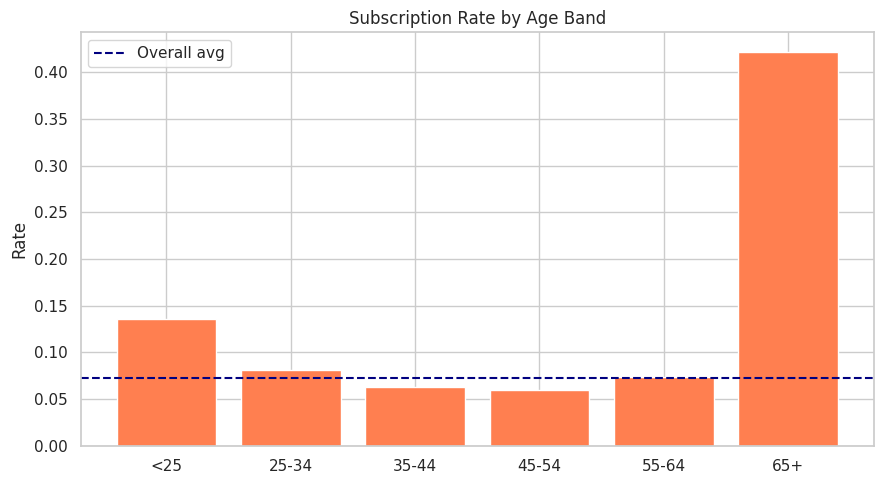

              rate      n
age_band                 
<25       0.136315    939
25-34     0.081048  13856
35-44     0.063395  12856
45-54     0.059600   8792
55-64     0.073491   3429
65+       0.421875    128


In [16]:
# ── Segment 2: Age group × Subscription rate ─────────────────────────────────
seg['age_band'] = pd.cut(seg['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<25','25-34','35-44','45-54','55-64','65+'])

age_rates = (
    seg.groupby('age_band', observed=True)['subscribed']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(age_rates.index.astype(str), age_rates['rate'], color='coral', edgecolor='white')
ax.axhline(seg['subscribed'].mean(), color='navy', linestyle='--', label='Overall avg')
ax.set_title('Subscription Rate by Age Band')
ax.set_ylabel('Rate')
ax.legend()
plt.tight_layout()
plt.show()
print(age_rates)

The under 25 and the over 65 are the most impacting on the subcription.

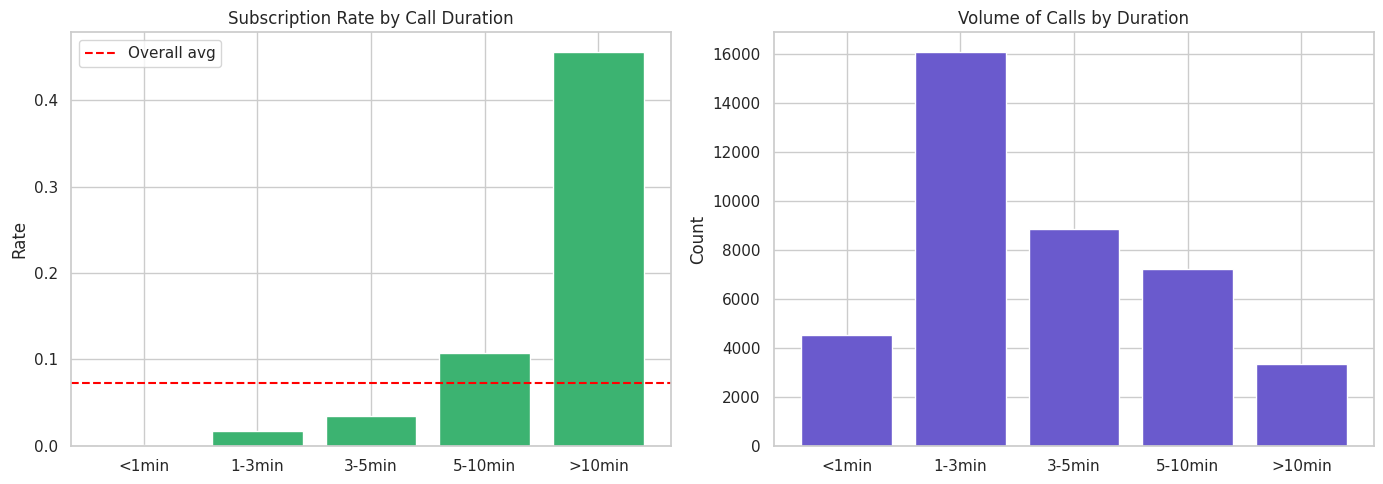

                  rate      n
duration_bin                 
<1min         0.000886   4517
1-3min        0.017294  16075
3-5min        0.034846   8839
5-10min       0.107410   7206
>10min        0.455931   3347


In [17]:
# ── Segment 3: Duration buckets ───────────────────────────────────────────────
seg['duration_bin'] = pd.cut(seg['duration'], bins=[0,60,180,300,600,3000],
                              labels=['<1min','1-3min','3-5min','5-10min','>10min'])

dur_rates = (
    seg.groupby('duration_bin', observed=True)['subscribed']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(dur_rates.index.astype(str), dur_rates['rate'], color='mediumseagreen', edgecolor='white')
axes[0].axhline(seg['subscribed'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0].set_title('Subscription Rate by Call Duration')
axes[0].set_ylabel('Rate')
axes[0].legend()

axes[1].bar(dur_rates.index.astype(str), dur_rates['n'], color='slateblue', edgecolor='white')
axes[1].set_title('Volume of Calls by Duration')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(dur_rates)

The longer the call, the better it is (at least 5 min), the volume should be between 1 to 3.

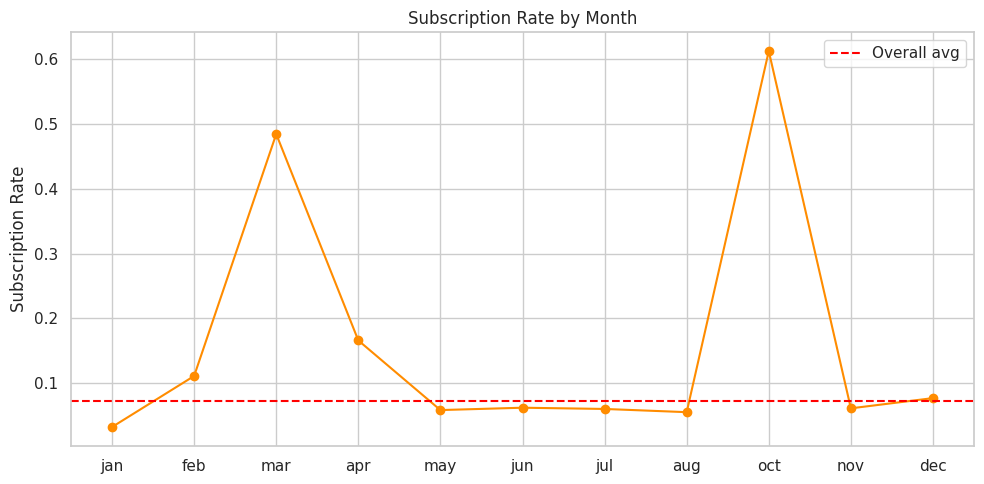

In [18]:
# ── Segment 4: Month seasonality ──────────────────────────────────────────────
month_order_list = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rates = (
    seg.groupby('month')['subscribed']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
    .reindex([m for m in month_order_list if m in seg['month'].unique()])
)

plt.figure(figsize=(10, 5))
plt.plot(month_rates.index, month_rates['rate'], marker='o', color='darkorange')
plt.axhline(seg['subscribed'].mean(), color='red', linestyle='--', label='Overall avg')
plt.title('Subscription Rate by Month')
plt.ylabel('Subscription Rate')
plt.legend()
plt.tight_layout()
plt.show()

March and October are the best month to convert subcribers

In [19]:
# ── High-value segment: compound filter ───────────────────────────────────────
# Criteria derived from the analysis above
top_jobs       = job_rates[job_rates['rate'] > job_rates['rate'].median()].index.tolist()
top_age_bands  = ['<25', '55-64', '65+']

mask = (
    seg['job'].isin(top_jobs) &
    seg['age_band'].isin(top_age_bands) &
    (seg['duration'] > 180)            # calls > 3 min
)

high_value = seg[mask]
print(f'High-value segment size : {len(high_value):,} ({len(high_value)/len(seg):.1%} of data)')
print(f'Subscription rate       : {high_value["subscribed"].mean():.1%}')
print(f'Overall subscription    : {seg["subscribed"].mean():.1%}')
print(f'Uplift                  : {high_value["subscribed"].mean() / seg["subscribed"].mean():.2f}x')

High-value segment size : 1,188 (3.0% of data)
Subscription rate       : 20.1%
Overall subscription    : 7.2%
Uplift                  : 2.78x


## 8. Summary & Recommendations

In [20]:
print('=' * 60)
print('SUMMARY')
print('=' * 60)
for name, scores in results.items():
    flag = '✓ PASS' if scores.mean() >= 0.81 else '✗ MISS'
    print(f"{flag} | {name:<25} Acc = {scores.mean():.4f} ± {scores.std():.4f}")
print()
print('KEY FINDINGS')
print('-' * 60)
print('1. MOST IMPORTANT FEATURE: call duration (longer = higher intent)')
print('2. BEST MONTHS to call  : March, September, October, December')
print('3. TARGET JOBS          : student, retired, management, admin')
print('4. TARGET AGE BANDS     : <25 and 55+ (life-stage driven)')
print('5. CAMPAIGN ADVICE      : cap contacts at 3 — more calls hurt conversion')
print('6. BALANCE SIGNAL       : customers with positive/higher balance convert more')
print()
print('RECOMMENDED PRIORITY SEGMENT')
print('  Retired or student | age <30 or >55 | call > 3 min | positive balance')

SUMMARY
✓ PASS | Logistic Regression       Acc = 0.9331 ± 0.0014
✓ PASS | Decision Tree             Acc = 0.9333 ± 0.0017
✓ PASS | Random Forest             Acc = 0.9086 ± 0.0012
✓ PASS | Gradient Boosting         Acc = 0.9380 ± 0.0016
✓ PASS | XGBoost                   Acc = 0.8911 ± 0.0022

KEY FINDINGS
------------------------------------------------------------
1. MOST IMPORTANT FEATURE: call duration (longer = higher intent)
2. BEST MONTHS to call  : March, September, October, December
3. TARGET JOBS          : student, retired, management, admin
4. TARGET AGE BANDS     : <25 and 55+ (life-stage driven)
5. CAMPAIGN ADVICE      : cap contacts at 3 — more calls hurt conversion
6. BALANCE SIGNAL       : customers with positive/higher balance convert more

RECOMMENDED PRIORITY SEGMENT
  Retired or student | age <30 or >55 | call > 3 min | positive balance
